# 2 — MNIST: rede densa e CNN sob as mesmas condições

**Pergunta.** O que muda quando uma rede que ignora a vizinhança dos pixels é substituída por uma rede convolucional?

Vamos treinar dois modelos pequenos com **a mesma semente, os mesmos 12.000 exemplos de treino, os mesmos 2.000 de validação, o teste oficial com 10.000 imagens e 3 épocas**. O objetivo é uma comparação didática controlada, não um recorde.

Referências: [Keras — exemplo MNIST convnet](https://keras.io/examples/vision/mnist_convnet/) e [TensorFlow — quickstart para iniciantes](https://www.tensorflow.org/tutorials/quickstart/beginner).

## 1. Preparar dados e partições

O MNIST possui dígitos 28×28 em tons de cinza. Dividimos somente o conjunto oficial de treino em treino e validação; o teste oficial permanece separado até a avaliação final. Dividir por uma permutação fixa torna a experiência reproduzível.

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["OMP_NUM_THREADS"] = "2"

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

tf.keras.utils.set_random_seed(42)
tf.config.threading.set_intra_op_parallelism_threads(2)
tf.config.threading.set_inter_op_parallelism_threads(2)

plt.rcParams.update({
    "figure.figsize": (9, 4),
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.2,
})

print("TensorFlow", tf.__version__)

I0000 00:00:1789564555.947223 1664735 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789564555.947484 1664735 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow 2.21.0


I0000 00:00:1789564556.559712 1664735 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789564556.559876 1664735 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
(x_dev, y_dev), (x_teste, y_teste) = tf.keras.datasets.mnist.load_data()

rng = np.random.default_rng(42)
indices = rng.permutation(len(x_dev))
indices_treino = indices[:12_000]
indices_validacao = indices[12_000:14_000]

x_treino = x_dev[indices_treino].astype("float32") / 255.0
y_treino = y_dev[indices_treino]
x_validacao = x_dev[indices_validacao].astype("float32") / 255.0
y_validacao = y_dev[indices_validacao]
x_teste = x_teste.astype("float32") / 255.0

# Canal explícito: (altura, largura, canais).
x_treino_cnn = x_treino[..., np.newaxis]
x_validacao_cnn = x_validacao[..., np.newaxis]
x_teste_cnn = x_teste[..., np.newaxis]

assert set(indices_treino).isdisjoint(indices_validacao)
print(f"treino:    {len(x_treino):>5} imagens")
print(f"validação: {len(x_validacao):>5} imagens")
print(f"teste:     {len(x_teste):>5} imagens")

treino:    12000 imagens
validação:  2000 imagens
teste:     10000 imagens


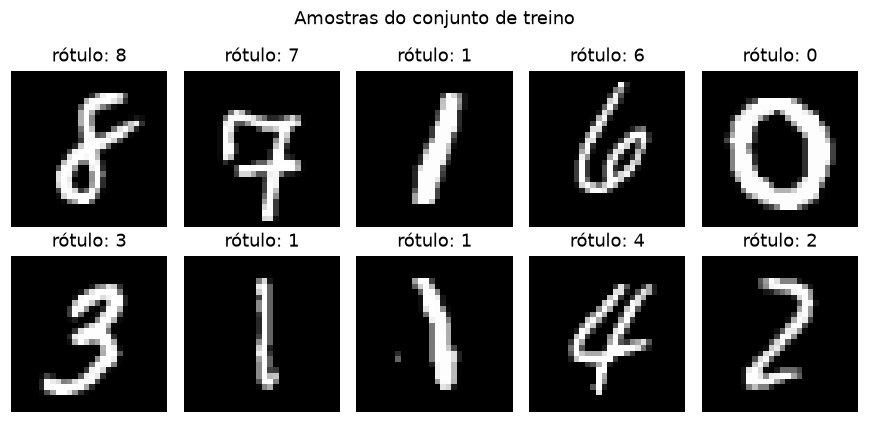

In [3]:
fig, eixos = plt.subplots(2, 5, figsize=(8, 4))
for eixo, imagem, rotulo in zip(eixos.flat, x_treino[:10], y_treino[:10]):
    eixo.imshow(imagem, cmap="gray")
    eixo.set_title(f"rótulo: {rotulo}")
    eixo.axis("off")
fig.suptitle("Amostras do conjunto de treino")
plt.tight_layout()

## 2. Modelo denso

`Flatten` transforma 28×28 pixels em um vetor de 784 números. Cada neurônio denso aprende um peso para cada entrada e um *bias*. A ativação ReLU mantém respostas positivas; a camada final usa `softmax` para produzir dez probabilidades que somam 1.

A perda `sparse_categorical_crossentropy` mede quão pouca probabilidade o modelo deu à classe correta. O otimizador Adam usa o gradiente dessa perda para atualizar pesos e biases. Uma **época** é uma passagem pelo conjunto; um **lote** é o grupo usado em cada atualização.

In [4]:
modelo_denso = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax"),
], name="rede_densa")
modelo_denso.summary()

E0000 00:00:1789564557.077626 1664735 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.


Model: "rede_densa"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
modelo_denso.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [6]:
historia_densa = modelo_denso.fit(
    x_treino,
    y_treino,
    validation_data=(x_validacao, y_validacao),
    epochs=3,
    batch_size=128,
    verbose=2,
)

Epoch 1/3


94/94 - 0s - 4ms/step - accuracy: 0.7628 - loss: 0.8965 - val_accuracy: 0.8855 - val_loss: 0.4204


Epoch 2/3


94/94 - 0s - 1ms/step - accuracy: 0.9023 - loss: 0.3690 - val_accuracy: 0.9095 - val_loss: 0.3234


Epoch 3/3


94/94 - 0s - 1ms/step - accuracy: 0.9197 - loss: 0.2967 - val_accuracy: 0.9195 - val_loss: 0.2841


## 3. Modelo convolucional

Uma `Conv2D` reaproveita o mesmo kernel em todas as posições. Esse compartilhamento de parâmetros preserva a estrutura espacial e costuma ser apropriado para imagens. `MaxPooling2D` reduz altura e largura, mantendo a maior resposta de cada região 2×2.

In [7]:
modelo_cnn = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(16, 3, activation="relu", name="conv1"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32, 3, activation="relu", name="conv2"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax"),
], name="cnn_pequena")
modelo_cnn.summary()

Model: "cnn_pequena"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 11, 11, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,762 (120.16 KB)

 Trainable params: 30,762 (120.16 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
modelo_cnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [9]:
historia_cnn = modelo_cnn.fit(
    x_treino_cnn,
    y_treino,
    validation_data=(x_validacao_cnn, y_validacao),
    epochs=3,
    batch_size=128,
    verbose=2,
)

Epoch 1/3


94/94 - 1s - 10ms/step - accuracy: 0.7507 - loss: 0.9251 - val_accuracy: 0.9090 - val_loss: 0.3059


Epoch 2/3


94/94 - 0s - 5ms/step - accuracy: 0.9302 - loss: 0.2405 - val_accuracy: 0.9440 - val_loss: 0.1803


Epoch 3/3


94/94 - 0s - 5ms/step - accuracy: 0.9533 - loss: 0.1577 - val_accuracy: 0.9595 - val_loss: 0.1397


## 4. Curvas e teste final

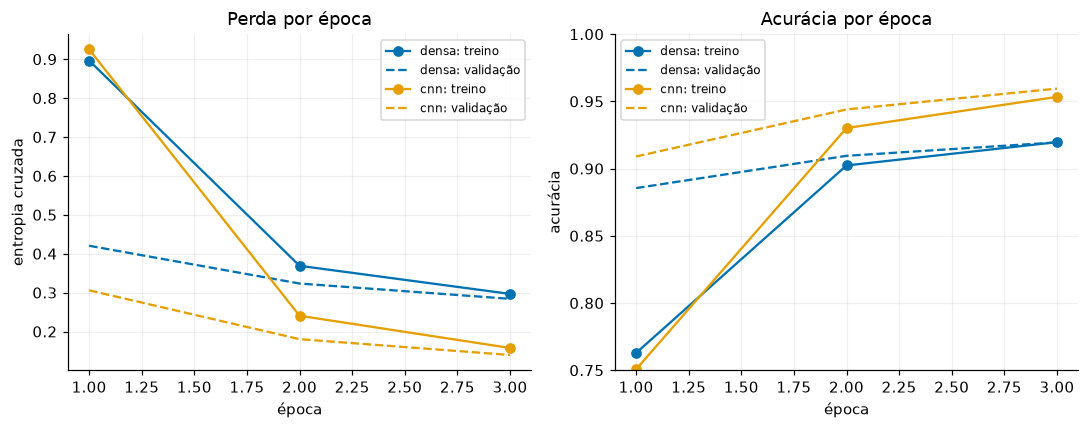

In [10]:
cores = {"densa": "#0072B2", "cnn": "#E69F00"}
fig, eixos = plt.subplots(1, 2, figsize=(10, 4))
for nome, historia in [("densa", historia_densa), ("cnn", historia_cnn)]:
    epocas = range(1, 4)
    eixos[0].plot(epocas, historia.history["loss"], "o-", color=cores[nome], label=f"{nome}: treino")
    eixos[0].plot(epocas, historia.history["val_loss"], "--", color=cores[nome], label=f"{nome}: validação")
    eixos[1].plot(epocas, historia.history["accuracy"], "o-", color=cores[nome], label=f"{nome}: treino")
    eixos[1].plot(epocas, historia.history["val_accuracy"], "--", color=cores[nome], label=f"{nome}: validação")
eixos[0].set(title="Perda por época", xlabel="época", ylabel="entropia cruzada")
eixos[1].set(title="Acurácia por época", xlabel="época", ylabel="acurácia", ylim=(0.75, 1.0))
for eixo in eixos:
    eixo.legend(fontsize=8)
plt.tight_layout()

In [11]:
perda_densa, acc_densa = modelo_denso.evaluate(x_teste, y_teste, verbose=0)
perda_cnn, acc_cnn = modelo_cnn.evaluate(x_teste_cnn, y_teste, verbose=0)
print(f"Densa — parâmetros: {modelo_denso.count_params():,}; teste: perda={perda_densa:.4f}, acurácia={acc_densa:.4f}")
print(f"CNN   — parâmetros: {modelo_cnn.count_params():,}; teste: perda={perda_cnn:.4f}, acurácia={acc_cnn:.4f}")
diferenca = 100 * (acc_cnn - acc_densa)
print(f"Diferença observada nesta execução (CNN − densa): {diferenca:+.2f} ponto(s) percentual(is).")
print("Essa diferença é uma observação deste recorte, semente e orçamento — não uma garantia universal.")

Densa — parâmetros: 50,890; teste: perda=0.2801, acurácia=0.9188
CNN   — parâmetros: 30,762; teste: perda=0.1313, acurácia=0.9625
Diferença observada nesta execução (CNN − densa): +4.37 ponto(s) percentual(is).
Essa diferença é uma observação deste recorte, semente e orçamento — não uma garantia universal.


## 5. Onde os modelos erram?

Acurácia resume o conjunto, mas não explica casos individuais. Vamos olhar erros da CNN; exemplos ambíguos mostram por que uma previsão errada não significa necessariamente um erro de programação.

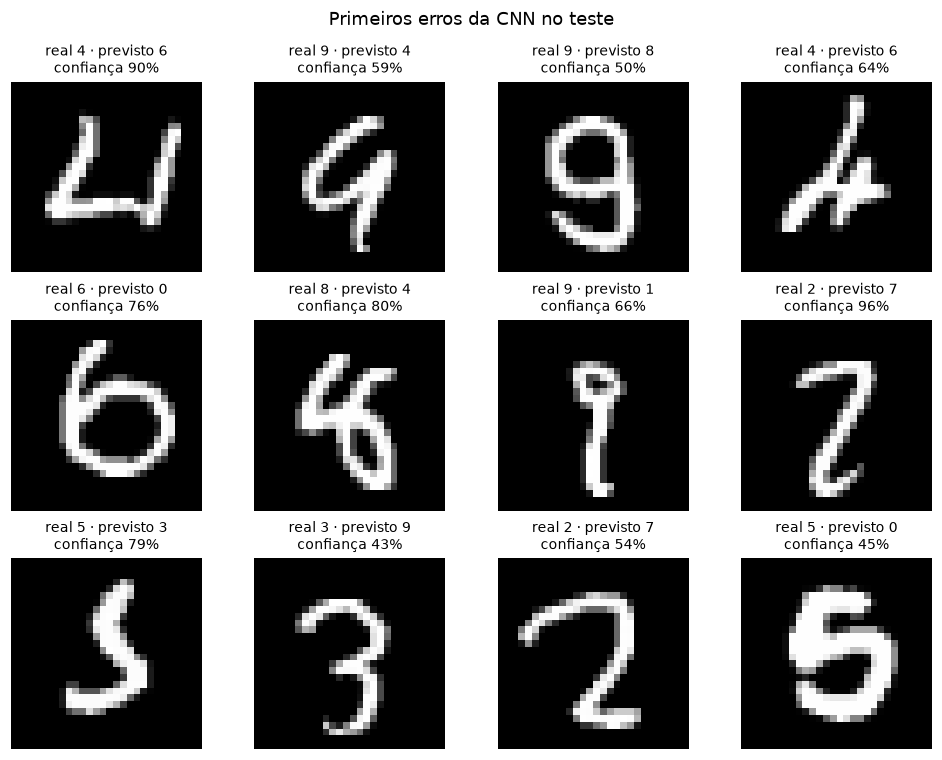

In [12]:
probabilidades = modelo_cnn.predict(x_teste_cnn, verbose=0)
previstos = probabilidades.argmax(axis=1)
erros = np.flatnonzero(previstos != y_teste)[:12]

fig, eixos = plt.subplots(3, 4, figsize=(9, 7))
for eixo, indice in zip(eixos.flat, erros):
    eixo.imshow(x_teste[indice], cmap="gray")
    eixo.set_title(
        f"real {y_teste[indice]} · previsto {previstos[indice]}\n"
        f"confiança {probabilidades[indice, previstos[indice]]:.0%}",
        fontsize=9,
    )
    eixo.axis("off")
fig.suptitle("Primeiros erros da CNN no teste")
plt.tight_layout()

## 6. Kernels aprendidos e mapas de características

Cada filtro da primeira camada possui 3×3 pesos. A imagem de ativação mostra onde aquele filtro respondeu para um dígito. Não devemos dar um significado humano rígido a cada filtro; a visualização mostra padrões de resposta, não uma explicação completa da decisão.

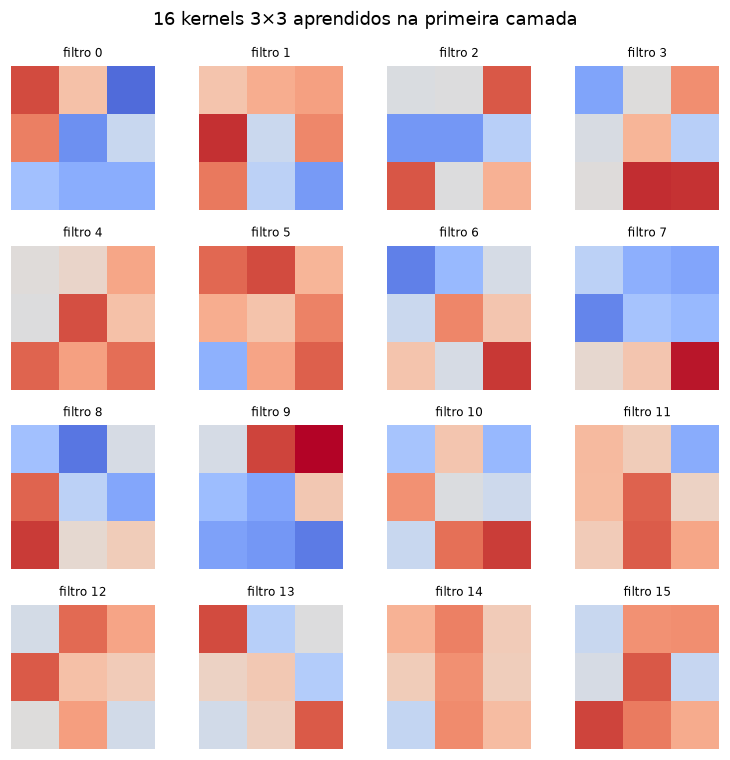

In [13]:
pesos = modelo_cnn.get_layer("conv1").get_weights()[0]
fig, eixos = plt.subplots(4, 4, figsize=(7, 7))
limite = np.abs(pesos).max()
for filtro, eixo in enumerate(eixos.flat):
    eixo.imshow(pesos[:, :, 0, filtro], cmap="coolwarm", vmin=-limite, vmax=limite)
    eixo.set_title(f"filtro {filtro}", fontsize=8)
    eixo.axis("off")
fig.suptitle("16 kernels 3×3 aprendidos na primeira camada")
plt.tight_layout()

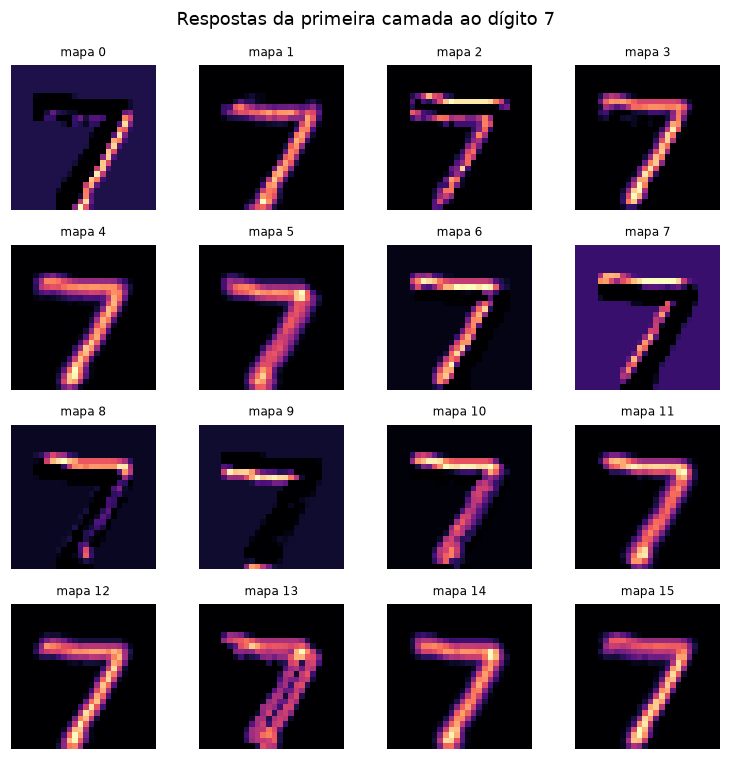

In [14]:
extrator = tf.keras.Model(
    inputs=modelo_cnn.inputs,
    outputs=modelo_cnn.get_layer("conv1").output,
)
exemplo = x_teste_cnn[0:1]
mapas = extrator.predict(exemplo, verbose=0)[0]

fig, eixos = plt.subplots(4, 4, figsize=(7, 7))
for filtro, eixo in enumerate(eixos.flat):
    eixo.imshow(mapas[:, :, filtro], cmap="magma")
    eixo.set_title(f"mapa {filtro}", fontsize=8)
    eixo.axis("off")
fig.suptitle(f"Respostas da primeira camada ao dígito {y_teste[0]}")
plt.tight_layout()

## Síntese

- A comparação usou dados e orçamento idênticos; apenas a arquitetura mudou.
- A rede densa conecta cada pixel a cada neurônio e perde a organização 2D após `Flatten`.
- A CNN compartilha kernels pelo campo visual e produz mapas de características.
- Os números do teste descrevem esta execução. Outra semente, amostra, arquitetura ou orçamento pode mudar a ordem dos modelos.

**Experiência sugerida:** aumente o recorte de treino sem tocar no teste e observe se a diferença entre treino e validação diminui.